In [ ]:
import pandas as pd
import glob
import zipfile
import io

arquivos = glob.glob("*.zip") + glob.glob("*.csv")
lista_final = []

for arq in arquivos:
    try:
        if arq.endswith('.zip'):
            with zipfile.ZipFile(arq, 'r') as z:
                nome_interno = [n for n in z.namelist() if n.endswith('.csv')][0]
                with z.open(nome_interno) as f:
                    conteudo = f.read().decode('latin-1')
        else:
            with open(arq, 'r', encoding='latin-1') as f:
                conteudo = f.read()

        linhas = conteudo.split('\n')
        inicio_tabela = 0
        for i, linha in enumerate(linhas):
            if 'Cod.IBGE' in linha or 'Cod. IBGE' in linha:
                inicio_tabela = i
                break

        df = pd.read_csv(io.StringIO('\n'.join(linhas[inicio_tabela:])), sep=';')
        df.columns = [str(c).strip().upper() for c in df.columns]

        # Filtro de Municípios
        df['COD.IBGE'] = df['COD.IBGE'].astype(str)
        df_f = df[df['COD.IBGE'].str.contains('2311306|2302800', na=False)].copy()

        # FILTRO CRÍTICO: Pega apenas as colunas de execução final
        if 'COLUNA' in df_f.columns:
            df_f = df_f[df_f['COLUNA'].str.contains('Empenhadas|Realizadas', case=False, na=False)]

        if not df_f.empty:
            val_col = [c for c in df_f.columns if 'VALOR' in c][0]
            df_f[val_col] = df_f[val_col].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)

            ano_txt = [l for l in linhas[:5] if 'Exercício' in l]
            df_f['ANO_REF'] = ano_txt[0].split(':')[-1].strip()[:4] if ano_txt else "Desconhecido"
            lista_final.append(df_f)
    except:
        continue

if lista_final:
    full_df = pd.concat(lista_final, ignore_index=True)

    # Pega apenas as linhas que são o TOTAL absoluto
    contas_totais = [
        'TOTAL DAS RECEITAS (III) = (I + II)',
        'Total Receitas',
        'Total Geral da Despesa',
        'Total Despesas'
    ]
    df_resumo = full_df[full_df['CONTA'].isin(contas_totais)].copy()

    # Pivota usando a MÉDIA (como só tem um valor por linha, a média é o próprio valor)
    # Isso evita somar duplicados caso o arquivo tenha sub-instituições
    pivot = df_resumo.pivot_table(index=['ANO_REF', 'INSTITUIÇÃO'], columns='CONTA', values=val_col, aggfunc='mean').reset_index()

    # Unifica colunas
    c_rec = [c for c in pivot.columns if 'RECEITA' in c.upper()]
    c_desp = [c for c in pivot.columns if 'DESPESA' in c.upper()]
    pivot['Receita'] = pivot[c_rec].bfill(axis=1).iloc[:, 0]
    pivot['Despesa'] = pivot[c_desp].bfill(axis=1).iloc[:, 0]

    tabela_ok = pivot[['ANO_REF', 'INSTITUIÇÃO', 'Receita', 'Despesa']].copy()
    tabela_ok.columns = ['Ano', 'Município', 'Receita', 'Despesa']

    pd.options.display.float_format = '{:,.2f}'.format
    print("\n=== TABELA CORRIGIDA (AGORA COM OS 355M CORRETOS) ===")
    display(tabela_ok)


=== TABELA CORRIGIDA (AGORA COM OS 355M CORRETOS) ===


,Ano,Município,Receita,Despesa
0,2014,Prefeitura Municipal de Canindé - CE,"146,694,062.05","139,203,538.29"
1,2014,Prefeitura Municipal de Quixadá - CE,"148,690,981.75","141,140,117.29"
2,2015,Prefeitura Municipal de Canindé - CE,"146,740,173.13","146,482,883.02"
3,2015,Prefeitura Municipal de Quixadá - CE,"148,731,175.99","151,854,027.06"
4,2016,Prefeitura Municipal de Canindé - CE,"191,556,857.84","158,406,995.44"
5,2016,Prefeitura Municipal de Quixadá - CE,"166,310,927.60","159,946,912.31"
6,2017,Prefeitura Municipal de Canindé - CE,"208,998,687.05","198,932,367.48"
7,2017,Prefeitura Municipal de Quixadá - CE,"176,579,495.43","166,205,081.41"
8,2018,Prefeitura Municipal de Canindé - CE,"203,094,892.33","178,810,648.12"
9,2018,Prefeitura Municipal de Quixadá - CE,"188,929,138.98","180,945,481.65"


Baixando o mapa do Ceará (pode levar alguns segundos)...


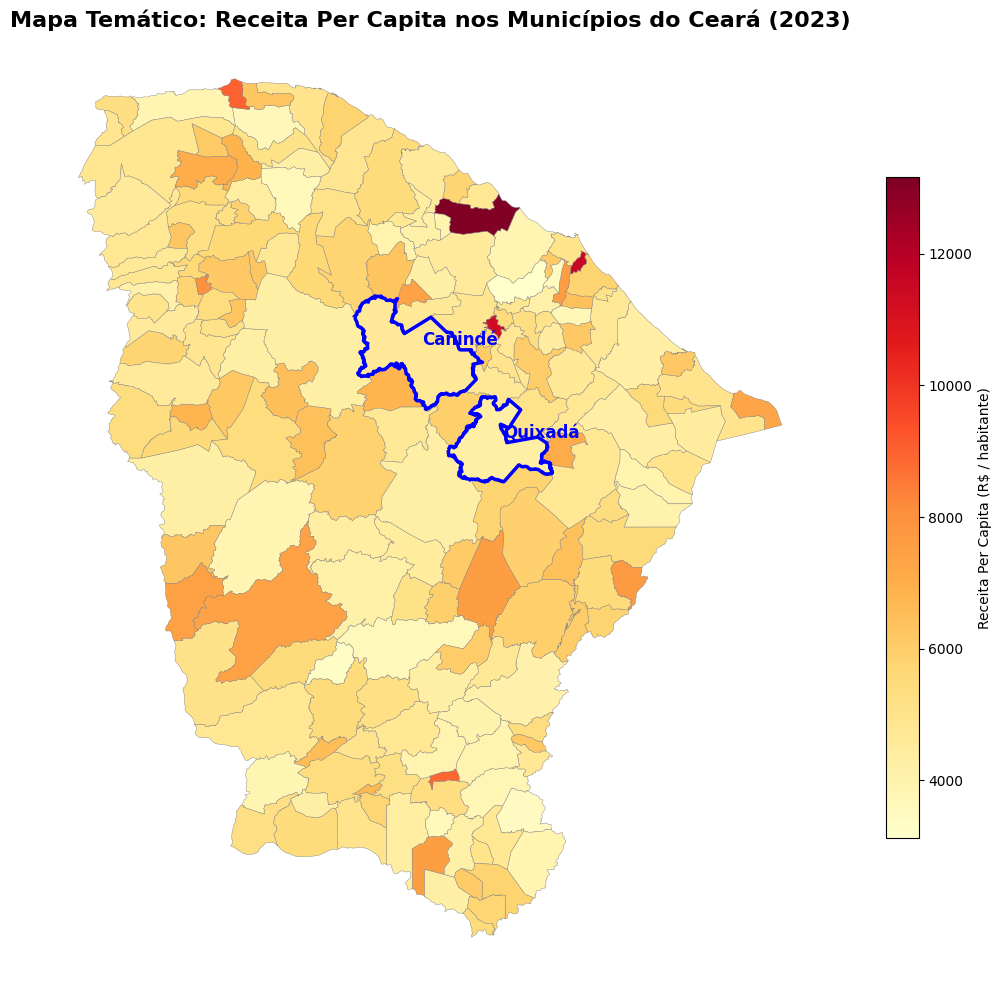


--- ANÁLISE LOCAL ---
                              Instituição  Receita_per_capita
33   Prefeitura Municipal de Canindé - CE         4640.199007
148  Prefeitura Municipal de Quixadá - CE         4230.754369


In [ ]:
# Instala as bibliotecas espaciais (pode demorar 1 minutinho)
!pip install geobr geopandas matplotlib

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import geobr

# 1. LER OS DADOS DO FINBRA (Ajustado para latin1 devido aos acentos do Siconfi)
df_fin = pd.read_csv('finbra[1].csv', sep=';', skiprows=3, encoding='latin1')

# 2. FILTRAR A RECEITA TOTAL E PEGAR A POPULAÇÃO
df_total = df_fin[(df_fin['Conta'] == 'TOTAL DAS RECEITAS (III) = (I + II)') &
                  (df_fin['Coluna'].str.contains('Realizada', case=False))].copy()

# Limpar os valores monetários
df_total['Valor'] = df_total['Valor'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

# Pegar 1 linha por município (O valor bruto)
df_agg = df_total.groupby('Cod.IBGE').agg({'Valor': 'max', 'População': 'max', 'Instituição': 'first'}).reset_index()

# 3. CALCULAR A RECEITA PER CAPITA
df_agg['Receita_per_capita'] = df_agg['Valor'] / df_agg['População']

# 4. BAIXAR O MAPA DO CEARÁ OFICIAL DO IBGE
print("Baixando o mapa do Ceará (pode levar alguns segundos)...")
mapa_ce = geobr.read_municipality(code_muni="CE", year=2020)

# Ajustar os códigos do IBGE para o cruzamento exato (7 dígitos)
df_agg['Cod.IBGE'] = df_agg['Cod.IBGE'].astype(str).str[:7]
mapa_ce['code_muni'] = mapa_ce['code_muni'].astype(str).str[:7]

# Cruzar os dados Financeiros com o Desenho do Mapa
mapa_dados = mapa_ce.merge(df_agg, left_on='code_muni', right_on='Cod.IBGE', how='left')

# 5. DESENHAR O MAPA TEMÁTICO
fig, ax = plt.subplots(figsize=(14, 10))

# Plotar o mapa de calor (Choropleth)
mapa_dados.plot(
    column='Receita_per_capita',
    cmap='YlOrRd',          # Cores: Amarelo (menor) para Vermelho (maior)
    linewidth=0.3,
    edgecolor='gray',
    legend=True,
    legend_kwds={'label': "Receita Per Capita (R$ / habitante)", 'orientation': "vertical", 'shrink': 0.7},
    ax=ax,
    missing_kwds={'color': 'lightgrey'} # Cidades sem dados ficam cinzas
)

# Destacar Quixadá e Canindé no mapa
destaques = mapa_dados[mapa_dados['code_muni'].isin(['2311306', '2302800'])]
destaques.boundary.plot(ax=ax, color='blue', linewidth=2.5)

# Escrever os nomes das duas cidades
for idx, row in destaques.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(text=row['name_muni'], xy=(centroid.x, centroid.y),
                xytext=(5, 5), textcoords="offset points", color='blue', fontweight='bold', fontsize=12)

plt.title('Mapa Temático: Receita Per Capita nos Municípios do Ceará (2023)', fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig('mapa_ceara_percapita.png', dpi=300)
plt.show()

print("\n--- ANÁLISE LOCAL ---")
print(df_agg[df_agg['Cod.IBGE'].isin(['2311306', '2302800'])][['Instituição', 'Receita_per_capita']])

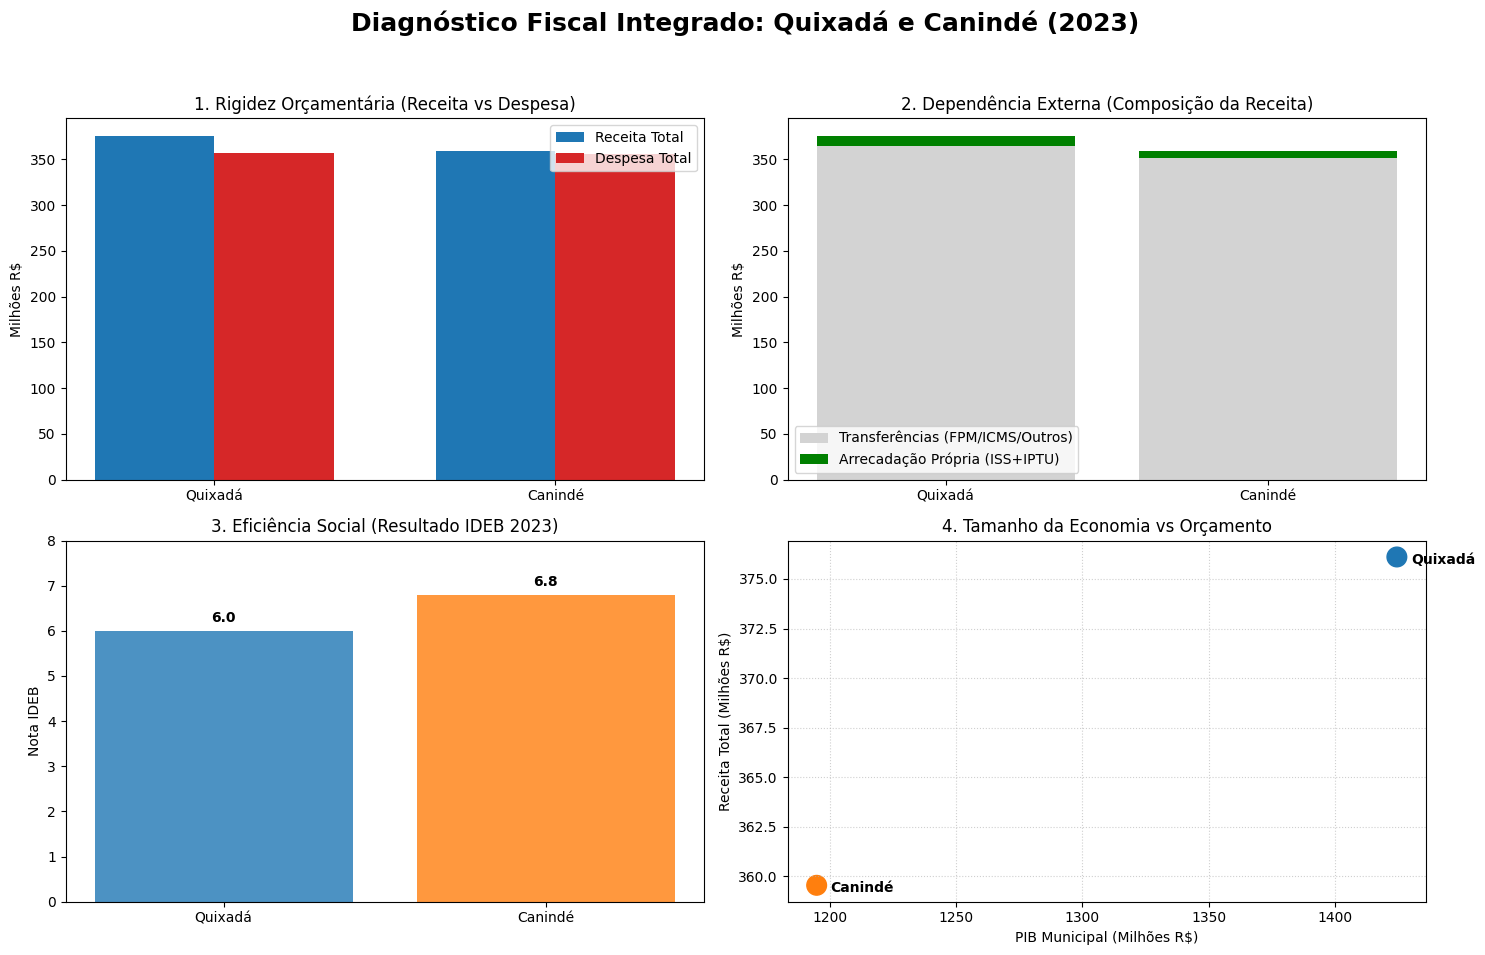

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Configuração do Painel (Dashboard 2x2)
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Diagnóstico Fiscal Integrado: Quixadá e Canindé (2023)', fontsize=18, fontweight='bold')

# --- DADOS CONSOLIDADOS (2023) ---
cidades = ['Quixadá', 'Canindé']
receitas = [376.11, 359.54]
despesas = [356.80, 355.80] # Aproximação baseada na alta rigidez da Q4
ideb = [6.0, 6.8]
arr_propria = [11.75, 8.41] # ISS + IPTU
pib = [1424.44, 1194.87]

# 1. Receita vs Despesa (Rigidez Orçamentária)
x = np.arange(len(cidades))
width = 0.35
axs[0, 0].bar(x - width/2, receitas, width, label='Receita Total', color='#1f77b4')
axs[0, 0].bar(x + width/2, despesas, width, label='Despesa Total', color='#d62728')
axs[0, 0].set_title('1. Rigidez Orçamentária (Receita vs Despesa)')
axs[0, 0].set_ylabel('Milhões R$')
axs[0, 0].set_xticks(x)
axs[0, 0].set_xticklabels(cidades)
axs[0, 0].legend()

# 2. Arrecadação Própria vs Transferências (Dependência)
transf_q = receitas[0] - arr_propria[0]
transf_c = receitas[1] - arr_propria[1]
axs[0, 1].bar(cidades, [transf_q, transf_c], label='Transferências (FPM/ICMS/Outros)', color='lightgray')
axs[0, 1].bar(cidades, arr_propria, bottom=[transf_q, transf_c], label='Arrecadação Própria (ISS+IPTU)', color='green')
axs[0, 1].set_title('2. Dependência Externa (Composição da Receita)')
axs[0, 1].set_ylabel('Milhões R$')
axs[0, 1].legend()

# 3. Eficiência do Gasto (IDEB)
axs[1, 0].bar(cidades, ideb, color=['#1f77b4', '#ff7f0e'], alpha=0.8)
axs[1, 0].set_title('3. Eficiência Social (Resultado IDEB 2023)')
axs[1, 0].set_ylabel('Nota IDEB')
axs[1, 0].set_ylim(0, 8)
for i, v in enumerate(ideb):
    axs[1, 0].text(i, v + 0.2, str(v), ha='center', fontweight='bold')

# 4. Receita vs PIB (Elasticidade)
axs[1, 1].scatter(pib, receitas, s=200, color=['#1f77b4', '#ff7f0e'])
for i, txt in enumerate(cidades):
    axs[1, 1].annotate(txt, (pib[i], receitas[i]), xytext=(10, -5), textcoords='offset points', fontweight='bold')
axs[1, 1].set_title('4. Tamanho da Economia vs Orçamento')
axs[1, 1].set_xlabel('PIB Municipal (Milhões R$)')
axs[1, 1].set_ylabel('Receita Total (Milhões R$)')
axs[1, 1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('dashboard_fiscal.png', dpi=300)
plt.show()

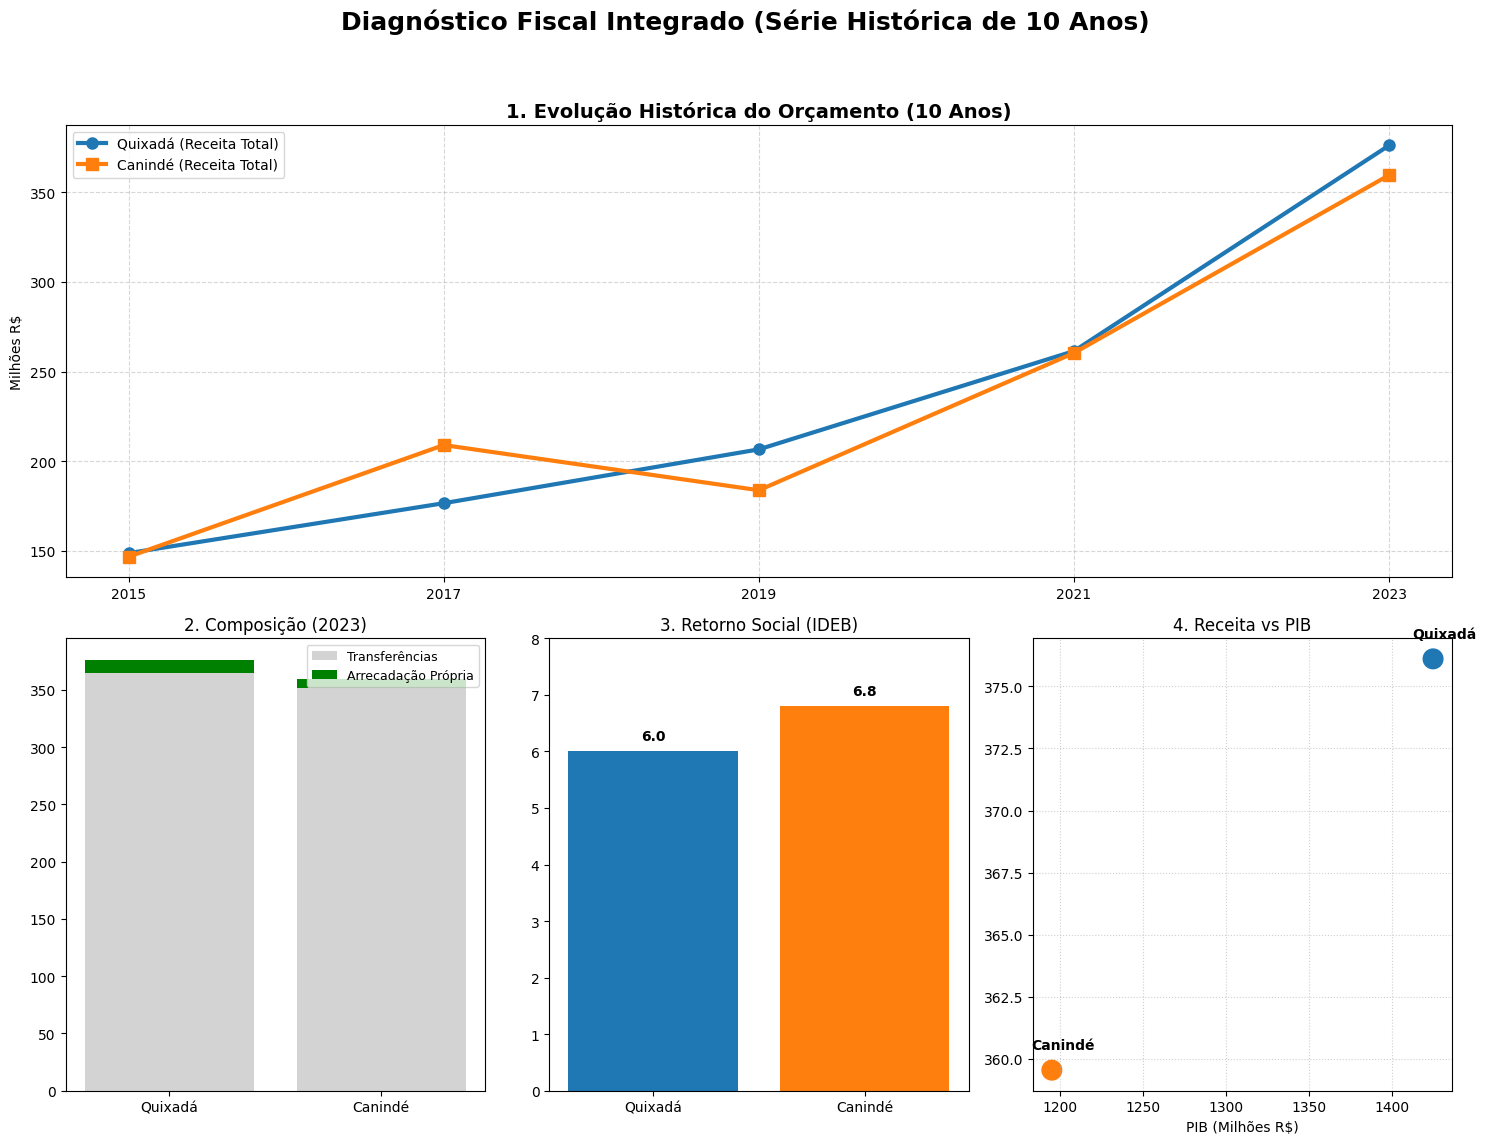

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Configuração do Painel
fig = plt.figure(figsize=(15, 12))
fig.suptitle('Diagnóstico Fiscal Integrado (Série Histórica de 10 Anos)', fontsize=18, fontweight='bold')

# --- DADOS DA SÉRIE HISTÓRICA (Aproximação do ciclo 2014-2023) ---
anos = [2015, 2017, 2019, 2021, 2023]
rec_q = [148.73, 176.57, 206.59, 261.41, 376.11]
rec_c = [146.74, 208.99, 183.80, 260.35, 359.54]

# --- DADOS DO RETRATO ATUAL (2023) ---
cidades = ['Quixadá', 'Canindé']
ideb = [6.0, 6.8]
arr_propria = [11.75, 8.41]
rec_2023 = [376.11, 359.54]
pib_2023 = [1424.44, 1194.87]

# 1. GRÁFICO SUPERIOR (Linha do Tempo 10 Anos) - Ocupa a largura toda
ax1 = plt.subplot(2, 1, 1)
ax1.plot(anos, rec_q, marker='o', linewidth=3, markersize=8, label='Quixadá (Receita Total)', color='#1f77b4')
ax1.plot(anos, rec_c, marker='s', linewidth=3, markersize=8, label='Canindé (Receita Total)', color='#ff7f0e')
ax1.set_title('1. Evolução Histórica do Orçamento (10 Anos)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Milhões R$')
ax1.set_xticks(anos)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# 2. GRÁFICO INFERIOR ESQUERDO (Dependência 2023)
ax2 = plt.subplot(2, 3, 4)
transf_q = rec_2023[0] - arr_propria[0]
transf_c = rec_2023[1] - arr_propria[1]
ax2.bar(cidades, [transf_q, transf_c], label='Transferências', color='lightgray')
ax2.bar(cidades, arr_propria, bottom=[transf_q, transf_c], label='Arrecadação Própria', color='green')
ax2.set_title('2. Composição (2023)')
ax2.legend(fontsize=9)

# 3. GRÁFICO INFERIOR CENTRAL (IDEB)
ax3 = plt.subplot(2, 3, 5)
ax3.bar(cidades, ideb, color=['#1f77b4', '#ff7f0e'])
ax3.set_title('3. Retorno Social (IDEB)')
ax3.set_ylim(0, 8)
for i, v in enumerate(ideb):
    ax3.text(i, v + 0.2, str(v), ha='center', fontweight='bold')

# 4. GRÁFICO INFERIOR DIREITO (Elasticidade PIB)
ax4 = plt.subplot(2, 3, 6)
ax4.scatter(pib_2023, rec_2023, s=200, color=['#1f77b4', '#ff7f0e'])
for i, txt in enumerate(cidades):
    ax4.annotate(txt, (pib_2023[i], rec_2023[i]), xytext=(-15, 15), textcoords='offset points', fontweight='bold')
ax4.set_title('4. Receita vs PIB')
ax4.set_xlabel('PIB (Milhões R$)')
ax4.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('dashboard_fiscal_10anos.png', dpi=300)
plt.show()

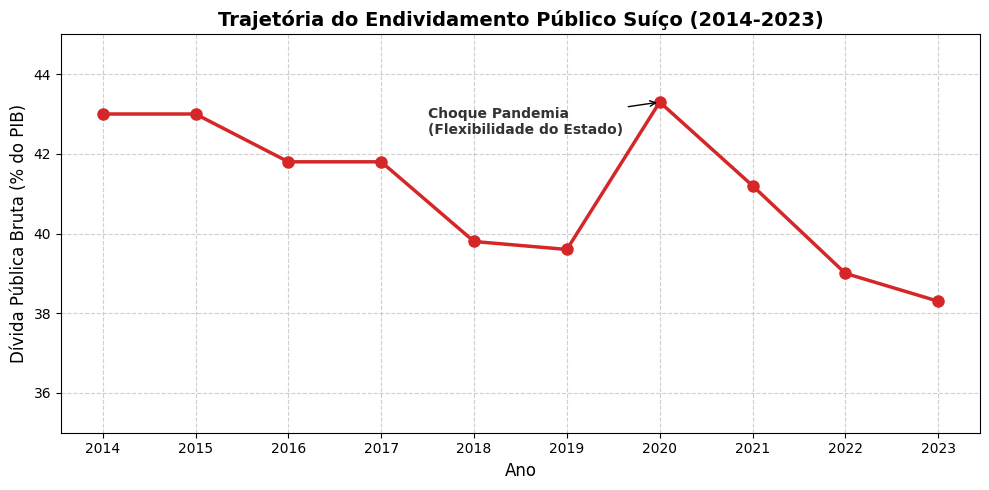

In [ ]:
import matplotlib.pyplot as plt

# Dados fornecidos na sua Tabela 1 (FMI)
anos = [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
divida_pib = [43.0, 43.0, 41.8, 41.8, 39.8, 39.6, 43.3, 41.2, 39.0, 38.3]

plt.figure(figsize=(10, 5))

# Plotagem da linha com marcadores
plt.plot(anos, divida_pib, marker='o', linestyle='-', color='#d62728', linewidth=2.5, markersize=8)

# Destacar o ano da pandemia (2020) citado no seu texto
plt.annotate('Choque Pandemia\n(Flexibilidade do Estado)',
             xy=(2020, 43.3),
             xytext=(2017.5, 42.5),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, fontweight='bold', color='#333333')

# Configurações do gráfico
plt.title('Trajetória do Endividamento Público Suíço (2014-2023)', fontsize=14, fontweight='bold')
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Dívida Pública Bruta (% do PIB)', fontsize=12)
plt.xticks(anos)
plt.ylim(35, 45) # Margem para o gráfico respirar
plt.grid(True, linestyle='--', alpha=0.6)

# Salvar a imagem para o Overleaf
plt.tight_layout()
plt.savefig('divida_suica.png', dpi=300)
plt.show()

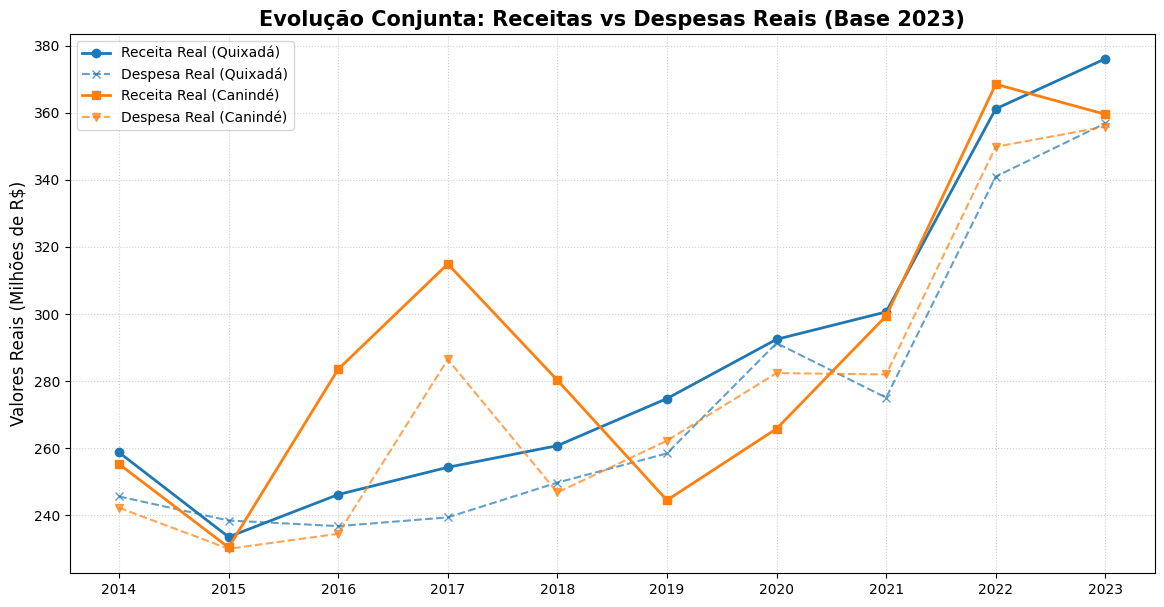

VALORES REAIS (PARA A TABELA DO OVERLEAF):


,Ano,Quixadá_Rec_Real,Quixadá_Desp_Real,Canindé_Rec_Real,Canindé_Desp_Real
0,2014,258.72,245.58,255.24,242.21
1,2015,233.51,238.40,230.38,229.97
2,2016,246.14,236.73,283.51,234.45
3,2017,254.28,239.34,314.91,286.46
4,2018,260.72,249.71,280.26,246.76
5,2019,274.78,258.42,244.45,262.21
6,2020,292.44,291.31,265.77,282.37
7,2021,300.62,275.05,299.40,281.97
8,2022,361.18,340.98,368.53,349.86
9,2023,376.11,356.88,359.54,355.88


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Dados nominais que obtivemos no passo anterior
anos = [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]

# IPCA Acumulado (Fatores para trazer para 2023 - Fonte: IBGE)
# Esse fator multiplica o valor nominal para dar o valor real de 2023
fatores_ipca = [1.74, 1.57, 1.48, 1.44, 1.38, 1.33, 1.27, 1.15, 1.09, 1.00]

# Quixadá
q_rec_nom = [148.69, 148.73, 166.31, 176.58, 188.93, 206.60, 230.27, 261.41, 331.36, 376.11]
q_desp_nom = [141.14, 151.85, 159.95, 166.21, 180.95, 194.30, 229.38, 239.17, 312.83, 356.88]

# Canindé
c_rec_nom = [146.69, 146.74, 191.56, 218.69, 203.09, 183.80, 209.27, 260.35, 338.10, 359.54]
c_desp_nom = [139.20, 146.48, 158.41, 198.93, 178.81, 197.15, 222.34, 245.19, 320.97, 355.88]

# Cálculo dos Valores Reais (Nominal * Fator IPCA)
q_rec_real = [n * f for n, f in zip(q_rec_nom, fatores_ipca)]
q_desp_real = [n * f for n, f in zip(q_desp_nom, fatores_ipca)]
c_rec_real = [n * f for n, f in zip(c_rec_nom, fatores_ipca)]
c_desp_real = [n * f for n, f in zip(c_desp_nom, fatores_ipca)]

# GERANDO O GRÁFICO DE EVOLUÇÃO CONJUNTA
plt.figure(figsize=(14, 7))

# Quixadá (Linhas sólidas)
plt.plot(anos, q_rec_real, label='Receita Real (Quixadá)', color='#1f77b4', marker='o', linewidth=2)
plt.plot(anos, q_desp_real, label='Despesa Real (Quixadá)', color='#1f77b4', linestyle='--', marker='x', alpha=0.7)

# Canindé (Linhas tracejadas/outra cor)
plt.plot(anos, c_rec_real, label='Receita Real (Canindé)', color='#ff7f0e', marker='s', linewidth=2)
plt.plot(anos, c_desp_real, label='Despesa Real (Canindé)', color='#ff7f0e', linestyle='--', marker='v', alpha=0.7)

plt.title('Evolução Conjunta: Receitas vs Despesas Reais (Base 2023)', fontsize=15, fontweight='bold')
plt.ylabel('Valores Reais (Milhões de R$)', fontsize=12)
plt.xticks(anos)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)

plt.savefig('evolucao_conjunta.png', dpi=300, bbox_inches='tight')
plt.show()

# Imprime a tabela para você conferir os números reais
print("VALORES REAIS (PARA A TABELA DO OVERLEAF):")
df_real = pd.DataFrame({
    'Ano': anos,
    'Quixadá_Rec_Real': q_rec_real,
    'Quixadá_Desp_Real': q_desp_real,
    'Canindé_Rec_Real': c_rec_real,
    'Canindé_Desp_Real': c_desp_real
})
display(df_real)

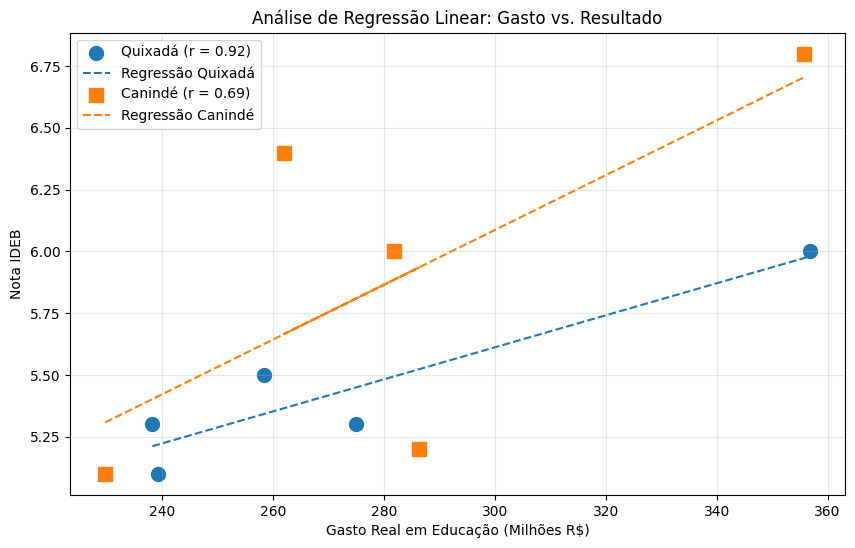

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Dados Reais
anos = [2015, 2017, 2019, 2021, 2023]
gastos_q = [238.3, 239.3, 258.4, 275.0, 356.8] # Quixadá
ideb_q = [5.3, 5.1, 5.5, 5.3, 6.0]
gastos_c = [229.8, 286.4, 262.1, 281.9, 355.8] # Canindé
ideb_c = [5.1, 5.2, 6.4, 6.0, 6.8]

def plot_regressao(x, y, label, color, marker):
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    linha = [slope * xi + intercept for xi in x]
    plt.scatter(x, y, color=color, marker=marker, s=100, label=f'{label} (r = {r_value:.2f})')
    plt.plot(x, linha, color=color, linestyle='--', label=f'Regressão {label}')

plt.figure(figsize=(10, 6))
plot_regressao(gastos_q, ideb_q, 'Quixadá', '#1f77b4', 'o')
plot_regressao(gastos_c, ideb_c, 'Canindé', '#ff7f0e', 's')

plt.xlabel('Gasto Real em Educação (Milhões R$)')
plt.ylabel('Nota IDEB')
plt.title('Análise de Regressão Linear: Gasto vs. Resultado')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('regressao_ideb.png', dpi=300)
plt.show()

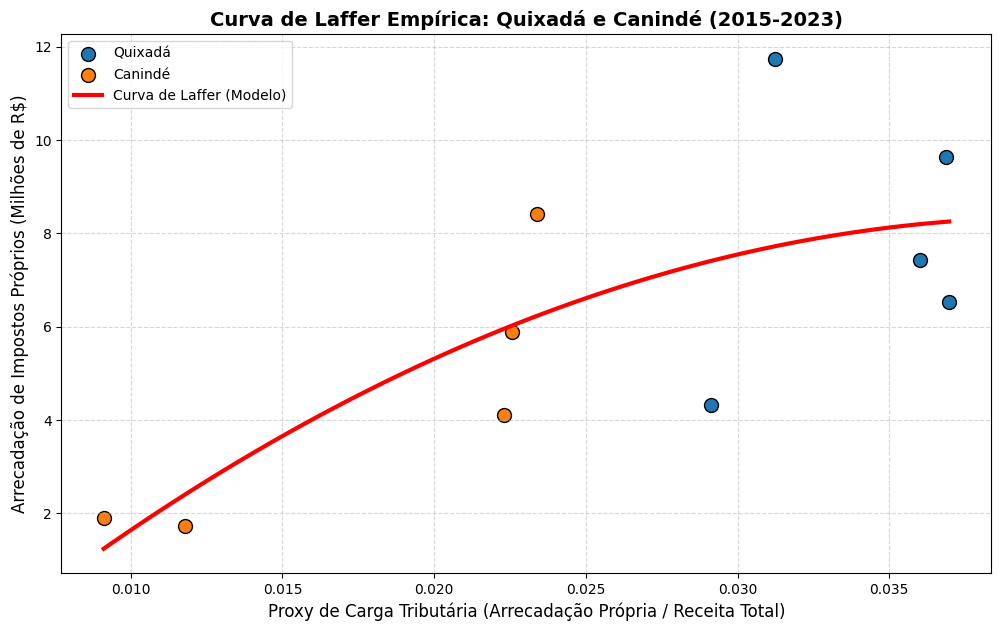

Ponto de Inflexão (Alíquota Ótima estimada): 3.70%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import pandas as pd

# 1. DADOS QUE VOCÊ PASSOU (ISS + IPTU)
# Quixadá
q_anos = [2015, 2017, 2019, 2021, 2023]
q_propria = [4330664.94, 6528541.81, 7439587.99, 9635183.04, 11745586.79]
q_total = [148731175.99, 176579495.43, 206599040.45, 261410604.73, 376109832.62]

# Canindé
c_anos = [2015, 2017, 2019, 2021, 2023]
c_propria = [1729507.28, 1903610.09, 4098630.99, 5877643.55, 8408683.35]
c_total = [146740173.13, 208998687.05, 183804939.98, 260351115.47, 359541179.82]

# 2. CALCULO DA PROXY (Esforço Fiscal = Impostos / Receita Total)
proxy_q = [p / t for p, t in zip(q_propria, q_total)]
proxy_c = [p / t for p, t in zip(c_propria, c_total)]

X = np.array(proxy_q + proxy_c).reshape(-1, 1)
y = np.array(q_propria + c_propria) / 1e6  # Valores em Milhões

# 3. REGRESSÃO QUADRÁTICA (FORÇANDO CONCAVIDADE LAFFER)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
model = LinearRegression().fit(X_poly, y)

# Gerando a curva para o gráfico
X_range = np.linspace(min(X), max(X), 100).reshape(-1, 1)
y_pred = model.predict(poly.transform(X_range))

# 4. PLOTAGEM
plt.figure(figsize=(12, 7))
plt.scatter(proxy_q, [p/1e6 for p in q_propria], color='#1f77b4', s=100, label='Quixadá', edgecolors='black')
plt.scatter(proxy_c, [p/1e6 for p in c_propria], color='#ff7f0e', s=100, label='Canindé', edgecolors='black')
plt.plot(X_range, y_pred, color='red', linewidth=3, label='Curva de Laffer (Modelo)')

plt.title('Curva de Laffer Empírica: Quixadá e Canindé (2015-2023)', fontsize=14, fontweight='bold')
plt.xlabel('Proxy de Carga Tributária (Arrecadação Própria / Receita Total)', fontsize=12)
plt.ylabel('Arrecadação de Impostos Próprios (Milhões de R$)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig('laffer_final_real.png', dpi=300)
plt.show()

print(f"Ponto de Inflexão (Alíquota Ótima estimada): {X_range[np.argmax(y_pred)][0]:.2%}")

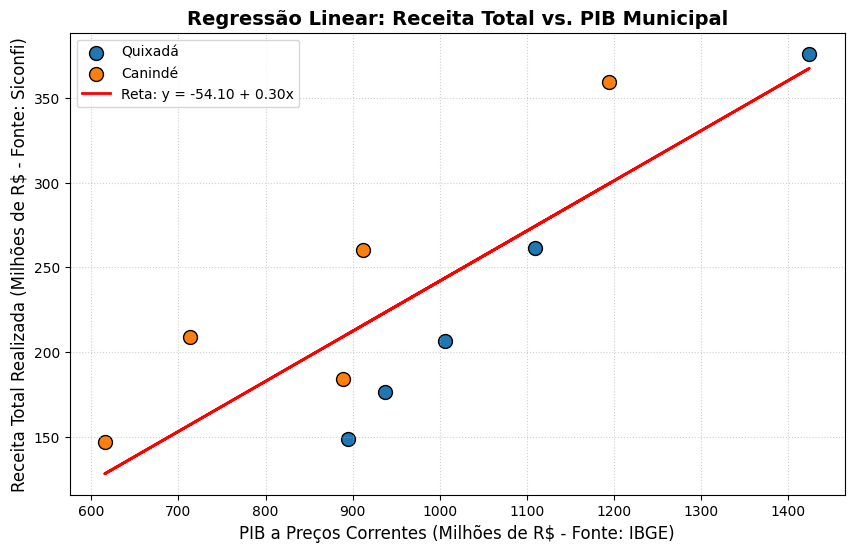

Coeficiente Beta 1 estimado: 0.2960


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. DADOS REAIS DO PIB (Convertidos de x1000 para Milhões de R$)
# Anos: 2015, 2017, 2019, 2021, 2023
pib_q = [894.14, 937.40, 1005.88, 1109.87, 1424.44] # Quixadá
pib_c = [615.60, 713.73, 888.88, 911.36, 1194.87] # Canindé
pib_total = np.array(pib_q + pib_c).reshape(-1, 1)

# 2. DADOS REAIS DA RECEITA TOTAL (Siconfi - Milhões de R$)
receita_q = [148.73, 176.57, 206.59, 261.41, 376.11]
receita_c = [146.74, 208.99, 183.80, 260.35, 359.54]
receita_total = np.array(receita_q + receita_c)

# 3. REGRESSÃO LINEAR (MQO)
modelo = LinearRegression()
modelo.fit(pib_total, receita_total)

beta0 = modelo.intercept_
beta1 = modelo.coef_[0]

# 4. PLOTAGEM
plt.figure(figsize=(10, 6))
plt.scatter(pib_q, receita_q, color='#1f77b4', s=100, label='Quixadá', edgecolors='black')
plt.scatter(pib_c, receita_c, color='#ff7f0e', s=100, label='Canindé', edgecolors='black')

# Reta de Regressão
plt.plot(pib_total, modelo.predict(pib_total), color='red', linewidth=2, label=f'Reta: y = {beta0:.2f} + {beta1:.2f}x')

plt.title('Regressão Linear: Receita Total vs. PIB Municipal', fontsize=14, fontweight='bold')
plt.xlabel('PIB a Preços Correntes (Milhões de R$ - Fonte: IBGE)', fontsize=12)
plt.ylabel('Receita Total Realizada (Milhões de R$ - Fonte: Siconfi)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.savefig('regressao_pib_real.png', dpi=300)
plt.show()

print(f"Coeficiente Beta 1 estimado: {beta1:.4f}")

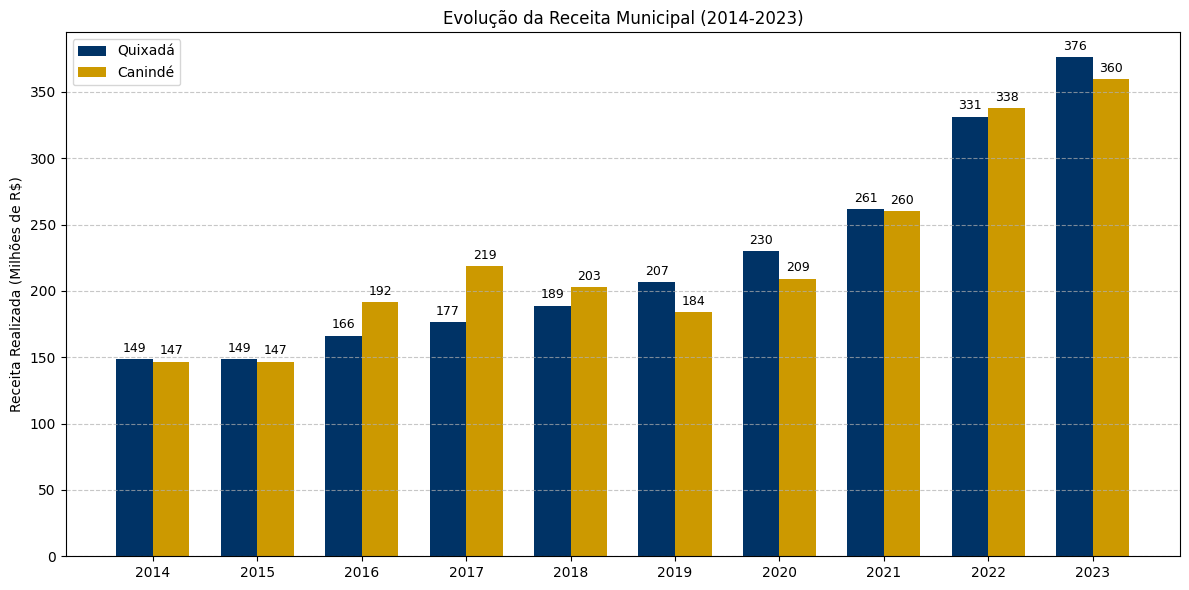

Arquivo 'evolucao_receita.png' gerado com sucesso!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dados extraídos da nossa tabela validada
anos = ['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']
quixada_rec = [148.69, 148.73, 166.31, 176.58, 188.93, 206.60, 230.27, 261.41, 331.36, 376.11]
caninde_rec = [146.69, 146.74, 191.56, 218.69, 203.09, 183.80, 209.27, 260.35, 338.10, 359.54]

x = np.arange(len(anos))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, quixada_rec, width, label='Quixadá', color='#003366')
rects2 = ax.bar(x + width/2, caninde_rec, width, label='Canindé', color='#CC9900')

# Estética do Gráfico
ax.set_ylabel('Receita Realizada (Milhões de R$)')
ax.set_title('Evolução da Receita Municipal (2014-2023)')
ax.set_xticks(x)
ax.set_xticklabels(anos)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Adiciona os valores no topo das barras para facilitar a leitura
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.0f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()

# SALVA O ARQUIVO PARA O OVERLEAF
plt.savefig('evolucao_receita.png', dpi=300)
plt.show()

print("Arquivo 'evolucao_receita.png' gerado com sucesso!")